# Task 2: Out-of-Sample Valuation Analysis

The valuation model is estimated using the historical sample through 2000. The fitted coefficients are then used to obtain predictions for 2021–2025.

`full-data.xlsx` begins in 1927. Construction of the return and dividend-growth variables requires the preceding observation, and the regression uses a lag of the cumulative process. The effective regression sample is therefore 1929–2000.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

from scipy.stats import shapiro, jarque_bera
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf

data = pd.read_excel("full-data.xlsx", sheet_name="data")
data[["Year", "Price", "Dividends"]].head()

,Year,Price,Dividends
0,1927,17.66,0.77
1,1928,24.35,0.85
2,1929,21.45,0.97
3,1930,15.34,0.98
4,1931,8.12,0.82


## 1. Valuation variables

Let $S_t$ denote the year-end S&P price level and $D_t$ the annual dividend. Define

$$
Q_t=\log(S_t+D_t)-\log(S_{t-1}),
$$

$$
G_t=\log(D_t)-\log(D_{t-1}),
$$

and

$$
X_t=Q_t-G_t.
$$

The cumulative process is

$$
C_t=\sum_{j\leq t}X_j.
$$

In [2]:
df = data[["Year", "Price", "Dividends"]].copy()

df["Q"] = np.log(df["Price"] + df["Dividends"]) - np.log(df["Price"].shift(1))
df["G"] = np.log(df["Dividends"]) - np.log(df["Dividends"].shift(1))
df["X"] = df["Q"] - df["G"]

df = df.dropna(subset=["X"]).copy()
df["C"] = df["X"].cumsum()
df["C_lag"] = df["C"].shift(1)
df["t"] = df["Year"] - 1927

print("First usable year:", int(df["Year"].min()))
print("Last available year:", int(df["Year"].max()))

First usable year: 1928
Last available year: 2025


## 2. Estimation

The model is

$$
X_t=\alpha+\beta t-\gamma C_{t-1}+Z_t.
$$

The equivalent parameters are

$$
b=1-\gamma,\qquad
c=\frac{\beta}{\gamma},\qquad
a=\alpha-bc.
$$

The detrended valuation measure is

$$
H_t=C_t-ct.
$$

In [3]:
train = df[(df["Year"] <= 2000)].dropna(subset=["C_lag"]).copy()

X_train = sm.add_constant(train[["t", "C_lag"]])
fit = sm.OLS(train["X"], X_train).fit()

alpha = fit.params["const"]
beta = fit.params["t"]
gamma = -fit.params["C_lag"]

b = 1 - gamma
c = beta / gamma
a = alpha - b*c

print("Regression sample:", int(train["Year"].min()), "-", int(train["Year"].max()))
print("Observations:", len(train))
print()
print("a =", round(a, 6))
print("b =", round(b, 6))
print("c =", round(c, 6))
print("trend =", round(100*c, 2), "%")

Regression sample: 1929 - 2000
Observations: 72

a = -0.073941
b = 0.741002
c = 0.057148
trend = 5.71 %


## 3. Confidence interval for the trend

Since $c=\beta/\gamma$, the interval uses the joint estimated covariance of $\widehat{\beta}$ and $\widehat{\gamma}$. The fitted coefficients are held fixed after estimation.

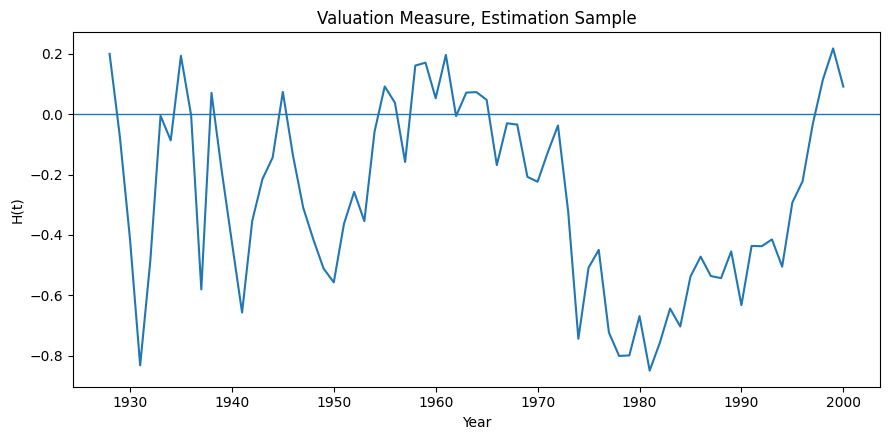

ADF statistic: -3.2792
ADF p-value: 0.0158
5% critical value: -2.9026


In [4]:
train_h = df[df["Year"] <= 2000].copy()
train_h["H"] = train_h["C"] - c*train_h["t"]

plt.figure(figsize=(9, 4.5))
plt.plot(train_h["Year"], train_h["H"])
plt.axhline(0, linewidth=1)
plt.xlabel("Year")
plt.ylabel("H(t)")
plt.title("Valuation Measure, Estimation Sample")
plt.tight_layout()
plt.show()

adf = adfuller(train_h["H"].dropna(), regression="c", autolag="AIC")

print("ADF statistic:", round(adf[0], 4))
print("ADF p-value:", round(adf[1], 4))
print("5% critical value:", round(adf[4]["5%"], 4))

## 4. Prediction, 2021–2025

For each year in the prediction period,

$$
\widehat{X}_t=
\widehat{\alpha}
+\widehat{\beta}t
-\widehat{\gamma}C_{t-1}.
$$

The predictions are compared with the observed values of $X_t=Q_t-G_t$.

In [5]:
cov_fit = fit.cov_params()

cov_bg = np.array([
    [cov_fit.loc["t", "t"], -cov_fit.loc["t", "C_lag"]],
    [-cov_fit.loc["C_lag", "t"], cov_fit.loc["C_lag", "C_lag"]]
])

rng = np.random.default_rng(2026)
draws = rng.multivariate_normal([beta, gamma], cov_bg, size=100000)
c_sim = draws[:, 0] / draws[:, 1]
ci_low, ci_high = np.quantile(c_sim, [0.025, 0.975])

print("Estimated trend:", round(100*c, 2), "%")
print("95% CI:", (round(100*ci_low, 2), round(100*ci_high, 2)), "%")

Estimated trend: 5.71 %
95% CI: (np.float64(4.77), np.float64(7.11)) %


## 5. Residual diagnostics

Diagnostics are based on the estimation sample. The residual ACF and Ljung-Box tests assess serial dependence in $Z_t$, while Ljung-Box tests on $Z_t^2$ check for dependence in the residual variance. Gaussianity is examined with the Q-Q plot, Shapiro-Wilk test, and Jarque-Bera test.

In [6]:
test = df[(df["Year"] >= 2021) & (df["Year"] <= 2025)].dropna(subset=["C_lag"]).copy()

test["Predicted_X"] = (
    alpha
    + beta*test["t"]
    - gamma*test["C_lag"]
)

test["Error"] = test["X"] - test["Predicted_X"]
test["Absolute_Error"] = test["Error"].abs()

forecast_table = test[
    ["Year", "X", "Predicted_X", "Error", "Absolute_Error"]
].copy()

forecast_table.columns = [
    "Year", "Actual", "Predicted", "Error", "Absolute Error"
]

print(forecast_table.round(4).to_string(index=False))

 Year  Actual  Predicted   Error  Absolute Error
 2021  0.2067     0.2170 -0.0102          0.0102
 2022 -0.2930     0.1782 -0.4713          0.4713
 2023  0.1823     0.2689 -0.0866          0.0866
 2024  0.1597     0.2365 -0.0768          0.0768
 2025  0.1100     0.2099 -0.0999          0.0999


In [7]:
rmse = np.sqrt(np.mean(test["Error"]**2))
mae = np.mean(test["Absolute_Error"])

print()
print("RMSE =", round(rmse, 4))
print("MAE  =", round(mae, 4))


RMSE = 0.2216
MAE  = 0.149


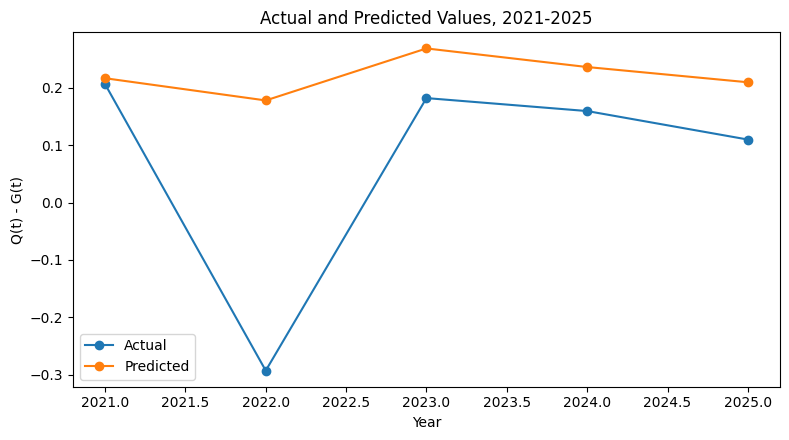

In [8]:
plt.figure(figsize=(8, 4.5))
plt.plot(test["Year"], test["X"], marker="o", label="Actual")
plt.plot(test["Year"], test["Predicted_X"], marker="o", label="Predicted")
plt.xlabel("Year")
plt.ylabel("Q(t) - G(t)")
plt.title("Actual and Predicted Values, 2021-2025")
plt.legend()
plt.tight_layout()
plt.show()

## 6. Summary

The coefficients are estimated only from observations through 2000. Observations from 2001–2020 are not used to re-estimate the model.

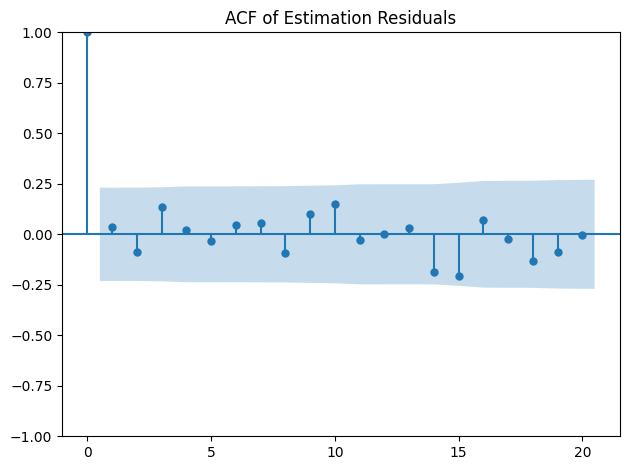

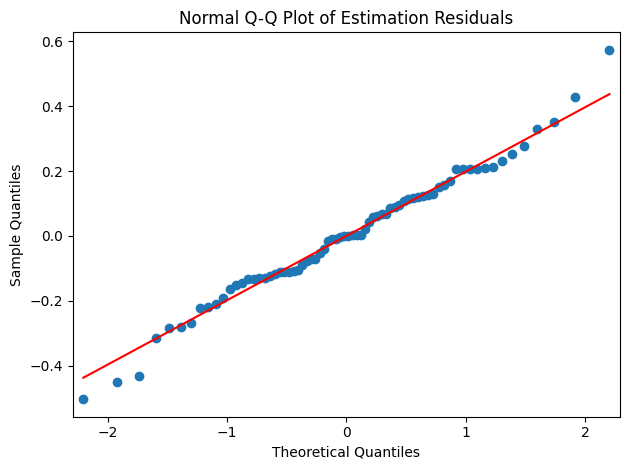

In [9]:
train["Z"] = fit.resid

plot_acf(train["Z"], lags=20)
plt.title("ACF of Estimation Residuals")
plt.tight_layout()
plt.show()

sm.qqplot(train["Z"], line="s")
plt.title("Normal Q-Q Plot of Estimation Residuals")
plt.tight_layout()
plt.show()

sw = shapiro(train["Z"])
jb = jarque_bera(train["Z"])

lb = acorr_ljungbox(train["Z"], lags=[5, 10], return_df=True)
lb2 = acorr_ljungbox(train["Z"]**2, lags=[5, 10], return_df=True)

In [10]:
print("Shapiro-Wilk p-value:", round(sw.pvalue, 4))
print("Jarque-Bera p-value:", round(jb.pvalue, 4))
print()
print("Ljung-Box for Z")
print(lb.round(4))
print()
print("Ljung-Box for Z^2")
print(lb2.round(4))

Shapiro-Wilk p-value: 0.8403
Jarque-Bera p-value: 0.7898

Ljung-Box for Z
    lb_stat  lb_pvalue
5    2.1870     0.8227
10   6.0919     0.8075

Ljung-Box for Z^2
    lb_stat  lb_pvalue
5   12.2440     0.0316
10  19.8001     0.0312


## 6. Summary

The model is estimated only from the historical sample available through 2000. The 2021–2025 observations are reserved for the requested prediction comparison. The gap between 2001 and 2020 is not used to re-estimate the model.

In [11]:
print("Effective regression sample:", int(train["Year"].min()), "-", int(train["Year"].max()))
print("Prediction period: 2021-2025")
print("b =", round(b, 4))
print("c =", round(100*c, 2), "%")
print("95% CI for c =", (round(100*ci_low, 2), round(100*ci_high, 2)), "%")
print("ADF p-value =", round(adf[1], 4))
print("RMSE =", round(rmse, 4))
print("MAE =", round(mae, 4))
print("Shapiro-Wilk p-value =", round(sw.pvalue, 4))
print("Ljung-Box p-value, lag 10 =", round(lb.loc[10, "lb_pvalue"], 4))
print("Ljung-Box Z^2 p-value, lag 10 =", round(lb2.loc[10, "lb_pvalue"], 4))

Effective regression sample: 1929 - 2000
Prediction period: 2021-2025
b = 0.741
c = 5.71 %
95% CI for c = (np.float64(4.77), np.float64(7.11)) %
ADF p-value = 0.0158
RMSE = 0.2216
MAE = 0.149
Shapiro-Wilk p-value = 0.8403
Ljung-Box p-value, lag 10 = 0.8075
Ljung-Box Z^2 p-value, lag 10 = 0.0312
